In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [6]:
path = '/content/drive/MyDrive/Colab Notebooks/wine.csv'
df = pd.read_csv(path)

In [19]:
y = df['Alcohol']
X = df.drop('Alcohol', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 168.9727 - mae: 12.9698 - val_loss: 161.0465 - val_mae: 12.6544
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 160.4128 - mae: 12.6385 - val_loss: 152.6795 - val_mae: 12.3203
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 151.9649 - mae: 12.2976 - val_loss: 143.8550 - val_mae: 11.9571
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 142.0061 - mae: 11.8855 - val_loss: 133.7681 - val_mae: 11.5269
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 129.5891 - mae: 11.3450 - val_loss: 122.2486 - val_mae: 11.0135
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 118.3580 - mae: 10.8334 - val_loss: 109.3761 - val_mae: 10.4084
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 105.2307 - mae: 10.1998 - val_loss: 95.3423 - val_mae: 9.7011
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 89.2413 - mae: 9.3727 - val_loss: 80.2653 - val_mae: 8.8721
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24

In [17]:
N_EPOCHS = 100

history=model.fit(x=X_train, y=y_train, epochs=N_EPOCHS, batch_size=32,validation_data= (X_test,y_test))
y_pred = model.predict(X_test)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3.7167 - mae: 1.5662 - val_loss: 3.5922 - val_mae: 1.4021
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.5638 - mae: 1.6932 - val_loss: 3.6068 - val_mae: 1.3855
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3.7181 - mae: 1.5370 - val_loss: 3.6064 - val_mae: 1.3809
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 3.5997 - mae: 1.5077 - val_loss: 3.6034 - val_mae: 1.3948
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.8496 - mae: 1.5803 - val_loss: 3.5943 - val_mae: 1.4007
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 3.9537 - mae: 1.5703 - val_loss: 3.5705 - val_mae: 1.3860
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 3.4891 - mae: 1.4459 - val_loss: 3.5551 - val_mae: 1.3911
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 4.0880 - mae: 1.5900 - val_loss: 3.5410 - val_mae: 1.4041
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 4.2987 - mae: 

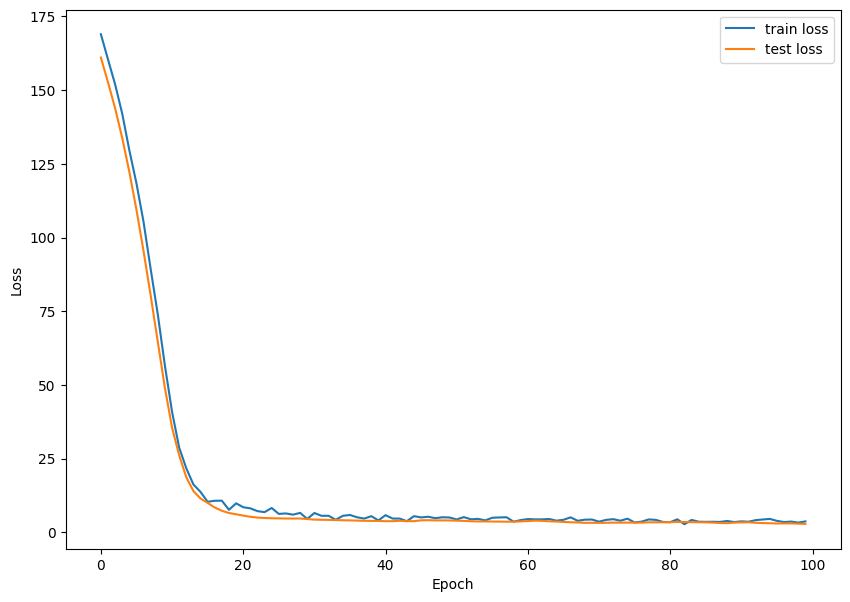

In [22]:
#학습 곡선
# loss 체크
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 5.0428 - mae: 1.7702
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


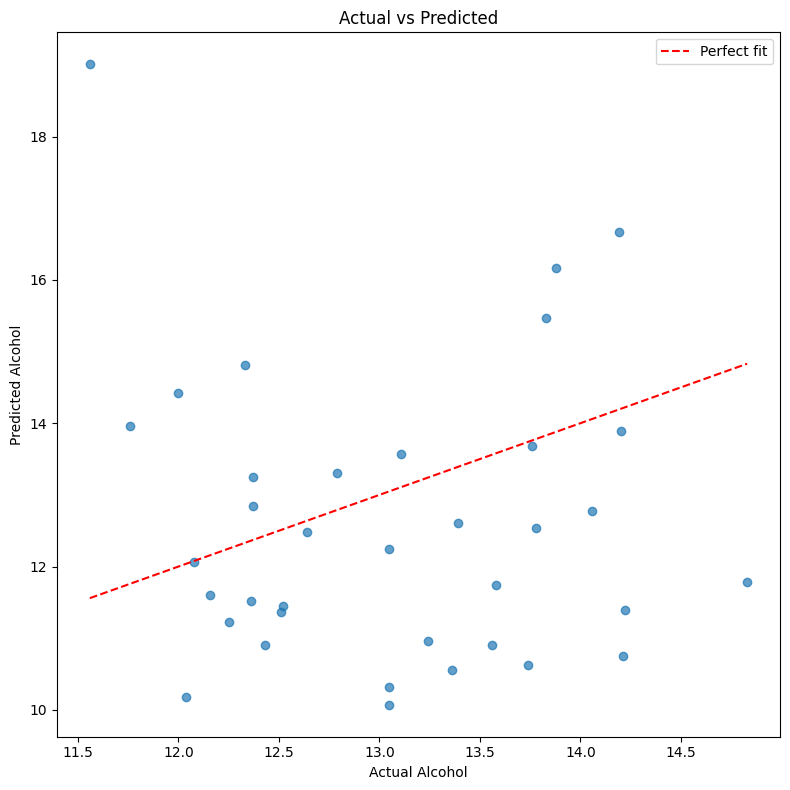

In [12]:

import matplotlib.pyplot as plt

model.evaluate(X_test, y_test)

y_pred = model.predict(X_test).flatten()

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Perfect fit')
plt.xlabel('Actual Alcohol')
plt.ylabel('Predicted Alcohol')
plt.title('Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.show()
